In [43]:

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd

df = pd.read_csv("trimmed-data-1.csv")

X = df.drop(columns=["Municipal", "Is Demolished", "Name"])
y = df["Municipal"]
X["Ward"] = X["Ward"].astype(str)
X = pd.get_dummies(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier(random_state=42, scale_pos_weight=807/175)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.89      0.92      0.90       160
        True       0.59      0.51      0.55        37

    accuracy                           0.84       197
   macro avg       0.74      0.72      0.73       197
weighted avg       0.84      0.84      0.84       197



In [44]:
model = XGBClassifier(
    random_state=42,
    scale_pos_weight=807/175,
    max_depth=3,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.86      0.83      0.85       160
        True       0.37      0.43      0.40        37

    accuracy                           0.76       197
   macro avg       0.62      0.63      0.62       197
weighted avg       0.77      0.76      0.76       197



In [45]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred_adjusted = (y_proba >= 0.3).astype(bool)
print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

       False       0.91      0.57      0.70       160
        True       0.29      0.76      0.42        37

    accuracy                           0.61       197
   macro avg       0.60      0.67      0.56       197
weighted avg       0.79      0.61      0.65       197



In [46]:
y_pred_adjusted = (y_proba >= 0.4).astype(bool)
print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

       False       0.91      0.72      0.81       160
        True       0.36      0.68      0.47        37

    accuracy                           0.72       197
   macro avg       0.63      0.70      0.64       197
weighted avg       0.80      0.72      0.74       197



In [47]:
# filter to undesignated buildings
undesignated = df[df["Municipal"] == False].copy()

# prepare features the same way as training
X_undesignated = undesignated.drop(columns=["Municipal"])
X_undesignated = pd.get_dummies(X_undesignated)

# align columns with training data in case get_dummies created different columns
X_undesignated = X_undesignated.reindex(columns=X_train.columns, fill_value=0)

# get probabilities
undesignated["probability"] = model.predict_proba(X_undesignated)[:, 1]

# rank by probability
results = undesignated[["Name", "Community", "Year of Construction", "probability"]].sort_values("probability", ascending=False)
print(results.head(20))
results.to_csv("results-basic.csv")

#Results of model are above (the ones displayed in the app)

                                          Name                 Community  \
255                          Court House No. 2  DOWNTOWN COMMERCIAL CORE   
215              Central Memorial Park Library                  BELTLINE   
24                      7 Street NW Boulevards                  ROSEDALE   
881                        Substation No. Four             SOUTH CALGARY   
116               Bow Valley Lawn Bowling Club                 HILLHURST   
464                  Hotel Cecil (Cecil Hotel)     DOWNTOWN EAST VILLAGE   
59                         Anderson Apartments         LOWER MOUNT ROYAL   
961                            Willingdon Hall               ASPEN WOODS   
562                  Louise (Hillhurst) Bridge                 HILLHURST   
760                     Rotary Park Lawn Bowls          CRESCENT HEIGHTS   
266                              Crescent Park          CRESCENT HEIGHTS   
768  Rutledge Hangar (Municipal Airport No. 1)                   RENFREW   
859         

In [48]:
import pickle
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

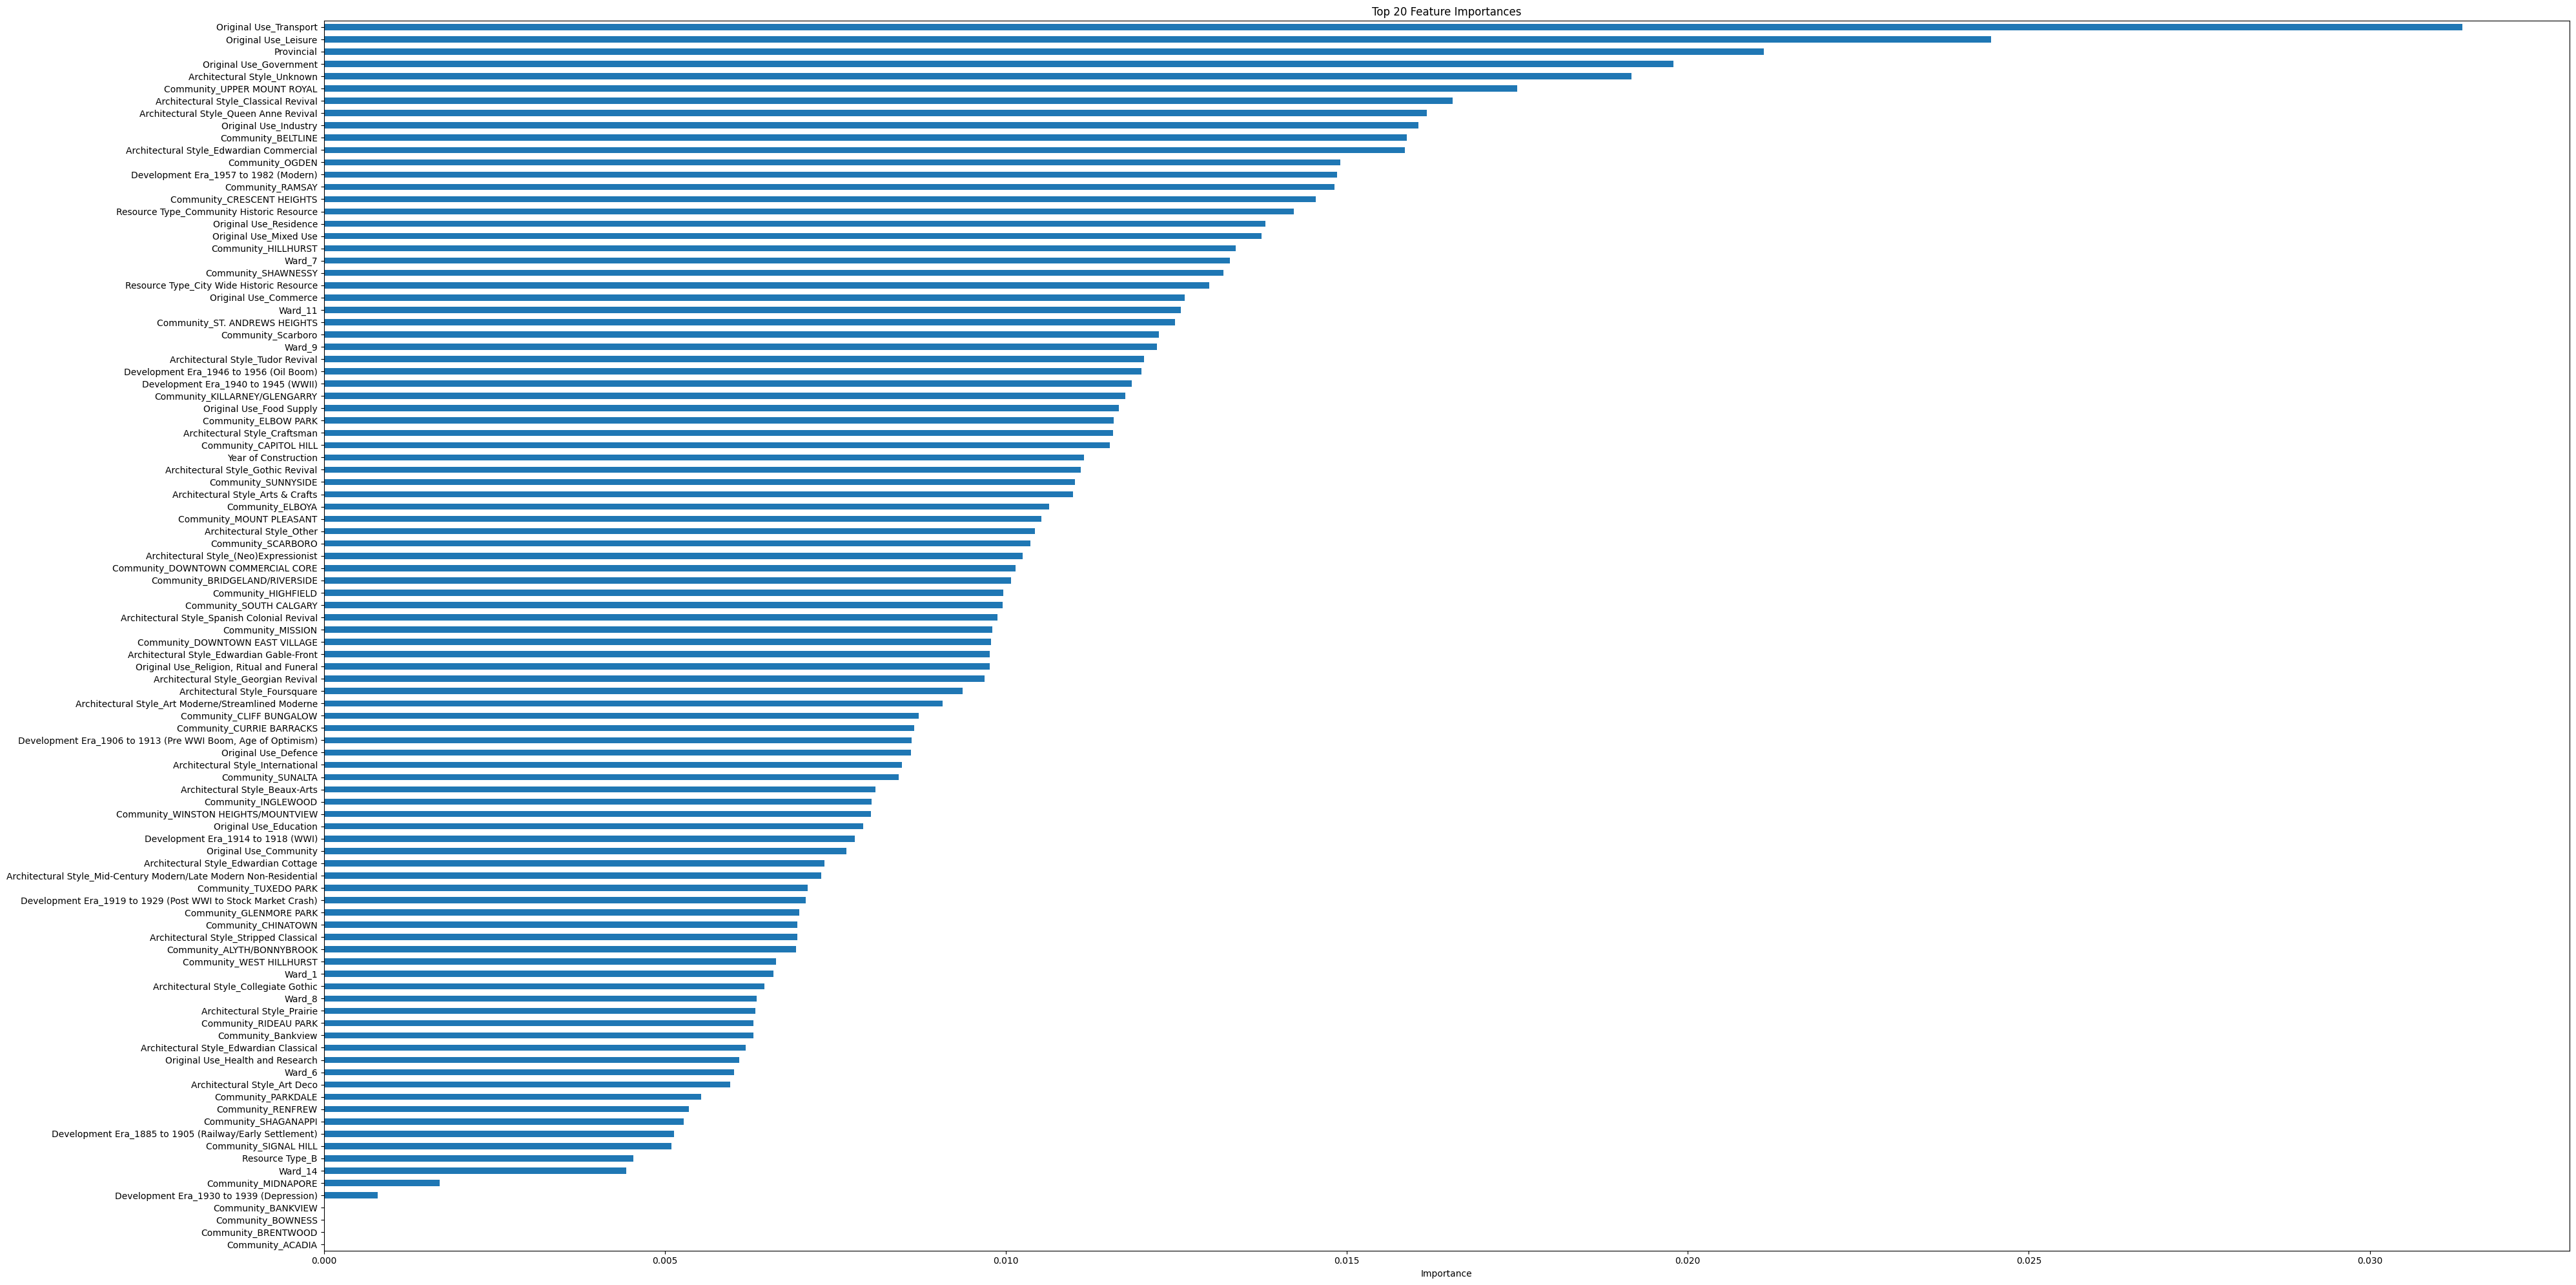

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(100)

feature_importance.plot(kind="barh", figsize=(40, 20))
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [50]:
y_train_pred = model.predict(X_train)
print("Train:")
print(classification_report(y_train, y_train_pred))
print("Test:")
print(classification_report(y_test, y_pred))

Train:
              precision    recall  f1-score   support

       False       0.96      0.87      0.92       647
        True       0.59      0.85      0.70       138

    accuracy                           0.87       785
   macro avg       0.78      0.86      0.81       785
weighted avg       0.90      0.87      0.88       785

Test:
              precision    recall  f1-score   support

       False       0.86      0.83      0.85       160
        True       0.37      0.43      0.40        37

    accuracy                           0.76       197
   macro avg       0.62      0.63      0.62       197
weighted avg       0.77      0.76      0.76       197



In [51]:
# We can see that our training data is getting 100% recall, need to generalize more

model = XGBClassifier(
    random_state=42,
    scale_pos_weight=807/175,
    max_depth=3,        # shallower trees = less memorization
    min_child_weight=5, # require more samples per leaf
    subsample=0.8,      # use 80% of data per tree
    colsample_bytree=0.8, # use 80% of features per tree
    reg_alpha=0.1,      # L1 regularization
    reg_lambda=1.0      # L2 regularization
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.89      0.82      0.85       160
        True       0.42      0.57      0.48        37

    accuracy                           0.77       197
   macro avg       0.66      0.69      0.67       197
weighted avg       0.80      0.77      0.78       197



In [52]:
y_train_pred = model.predict(X_train)
print("Train:")
print(classification_report(y_train, y_train_pred))
print("Test:")
print(classification_report(y_test, y_pred))

Train:
              precision    recall  f1-score   support

       False       0.96      0.84      0.90       647
        True       0.53      0.83      0.65       138

    accuracy                           0.84       785
   macro avg       0.74      0.83      0.77       785
weighted avg       0.88      0.84      0.85       785

Test:
              precision    recall  f1-score   support

       False       0.89      0.82      0.85       160
        True       0.42      0.57      0.48        37

    accuracy                           0.77       197
   macro avg       0.66      0.69      0.67       197
weighted avg       0.80      0.77      0.78       197



*Note* False positives in this case lead to wasted time/effort of the HC staff
  False Negatives means a potential missed site that would have designated.

  Prioritizing recall over precision means that we are prioritizing not missing potential site that would designate.

  Prioritizing precision would instead prioritize HC time

  Given that the inventory is relatively limited, missing a potential designation site seems worse than just wasting a bit of time/effort,
  Of course if they are prioritizing short term vs long term gains this could be different, but thinking longer term here.

  